# RSSI Data Analysis — Indoor Positioning

**Ziel:** Überblick über die BLE-RSSI-Daten gewinnen, Positionswahrscheinlichkeiten schätzen und Fehlerrate ermitteln.

**Methode:** Log-Distance Path Loss Model → Distanzschätzung → Multilateration (Least Squares)

**Datenquelle:** `emi_nav.db` — Tabellen `runs`, `ble_rssi`, `beacon_positions`, `door_positions`, `groundtruth`

**Referenz:** PositionEstimation.pdf (Prof. Dr. Gerald Pirkl, OTH Amberg-Weiden)

## 0 — Imports & Config

In [121]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

DB_PATH = '../data/emi_nav.db'

# Path Loss Modell Parameter (kalibriert auf ~1m Messung)
RSSI_0           = -54.0  # dBm bei d=1m
PATH_LOSS_EXP    =   3.0  # Innenraum-Exponent
FLOOR_PENALTY_DB =   3.0  # dB Verlust pro Stockwerk

print('Config geladen ✓')

Config geladen ✓


## 1 — Daten laden

In [122]:
conn = sqlite3.connect(DB_PATH)

runs_df   = pd.read_sql('SELECT * FROM runs', conn)
rssi_df   = pd.read_sql('SELECT * FROM ble_rssi', conn)

# Beacon-Positionen aus DB
beacon_pos_df = pd.read_sql('SELECT * FROM beacon_positions', conn)
BEACON_POSITIONS = {
    row.beacon_name: (row.x_m, row.y_m, row.floor)
    for row in beacon_pos_df.itertuples()
}

# Door-Positionen + Groundtruth per JOIN aus DB
gt_df = pd.read_sql("""
    SELECT g.run_id, g.tuer_id, g.timestamp_ms,
           d.x_m, d.y_m, d.floor
    FROM groundtruth g
    JOIN door_positions d ON g.tuer_id = d.tuer_id
    WHERE d.x_m IS NOT NULL AND d.y_m IS NOT NULL
""", conn)

conn.close()

# Outlier + fremde Beacons raus
rssi_df = rssi_df[rssi_df['beacon_name'].str.startswith('arrive_emi')].copy()
rssi_df = rssi_df[rssi_df['rssi'] <= 0].copy()

print(f'Runs: {len(runs_df)}')
print(f'RSSI-Messungen (gefiltert): {len(rssi_df)}')
print(f'Beacon-Positionen geladen: {len(BEACON_POSITIONS)}')
print(f'Groundtruth-Punkte (mit Koordinaten): {len(gt_df)}')
print('\nBeacons:', list(BEACON_POSITIONS.keys()))
print('\nGroundtruth:')
print(gt_df)

Runs: 3
RSSI-Messungen (gefiltert): 3682
Beacon-Positionen geladen: 6
Groundtruth-Punkte (mit Koordinaten): 20

Beacons: ['arrive_emi1', 'arrive_emi2', 'arrive_emi3', 'arrive_emi4', 'arrive_emi8', 'arrive_emi10']

Groundtruth:
   run_id tuer_id   timestamp_ms    x_m   y_m  floor
0      R1     H01  1781612164000  120.0  12.0      0
1      R1     H02  1781612171000  117.4   6.2      0
2      R1    T022  1781612192000   95.0   4.4      0
3      R1     H03  1781612206000   79.2   6.0      0
4      R2     H03  1781614938000   79.2   6.0      0
5      R2     H13  1781614972000   79.2   6.0      1
6      R2     H12  1781614998000  117.4   6.2      1
7      R2     H11  1781615013000  120.0  12.0      1
8      R2     H01  1781615036000  120.0  12.0      0
9      R2     H02  1781615043000  117.4   6.2      0
10     R3    T125  1781615285000   65.0   6.6      1
11     R3     H13  1781615296000   79.2   6.0      1
12     R3   T109c  1781615320000   96.0   8.0      1
13     R3     H12  178161535000

## 2 — Explorative Datenanalyse (EDA)

In [123]:
print('=== Allgemeine Stats ===')
print(rssi_df.describe())
print('\n=== Messungen pro Run & Beacon ===')
print(rssi_df.groupby(['run_id', 'beacon_name'])['rssi'].agg(['count','mean','std','min','max']).round(2))

=== Allgemeine Stats ===
                id  timestamp_ms         rssi
count  3682.000000  3.682000e+03  3682.000000
mean   1889.642857  1.781615e+12   -85.015752
std    1088.725381  1.068175e+06     8.612915
min       1.000000  1.781612e+12  -105.000000
25%     945.250000  1.781615e+12   -91.000000
50%    1885.500000  1.781615e+12   -86.000000
75%    2834.750000  1.781615e+12   -80.000000
max    3772.000000  1.781616e+12   -54.000000

=== Messungen pro Run & Beacon ===
                     count   mean    std    min   max
run_id beacon_name                                   
R1     arrive_emi1      16 -95.12   4.10 -100.0 -87.0
       arrive_emi10    142 -85.38   7.68 -100.0 -63.0
       arrive_emi2      77 -86.66   7.05 -102.0 -70.0
       arrive_emi3      55 -91.25   3.97  -99.0 -84.0
       arrive_emi4     141 -80.62  10.33 -102.0 -63.0
       arrive_emi8      73 -84.37   7.40 -101.0 -71.0
R2     arrive_emi1     203 -84.49   7.81 -102.0 -66.0
       arrive_emi10    225 -84.88   9.4

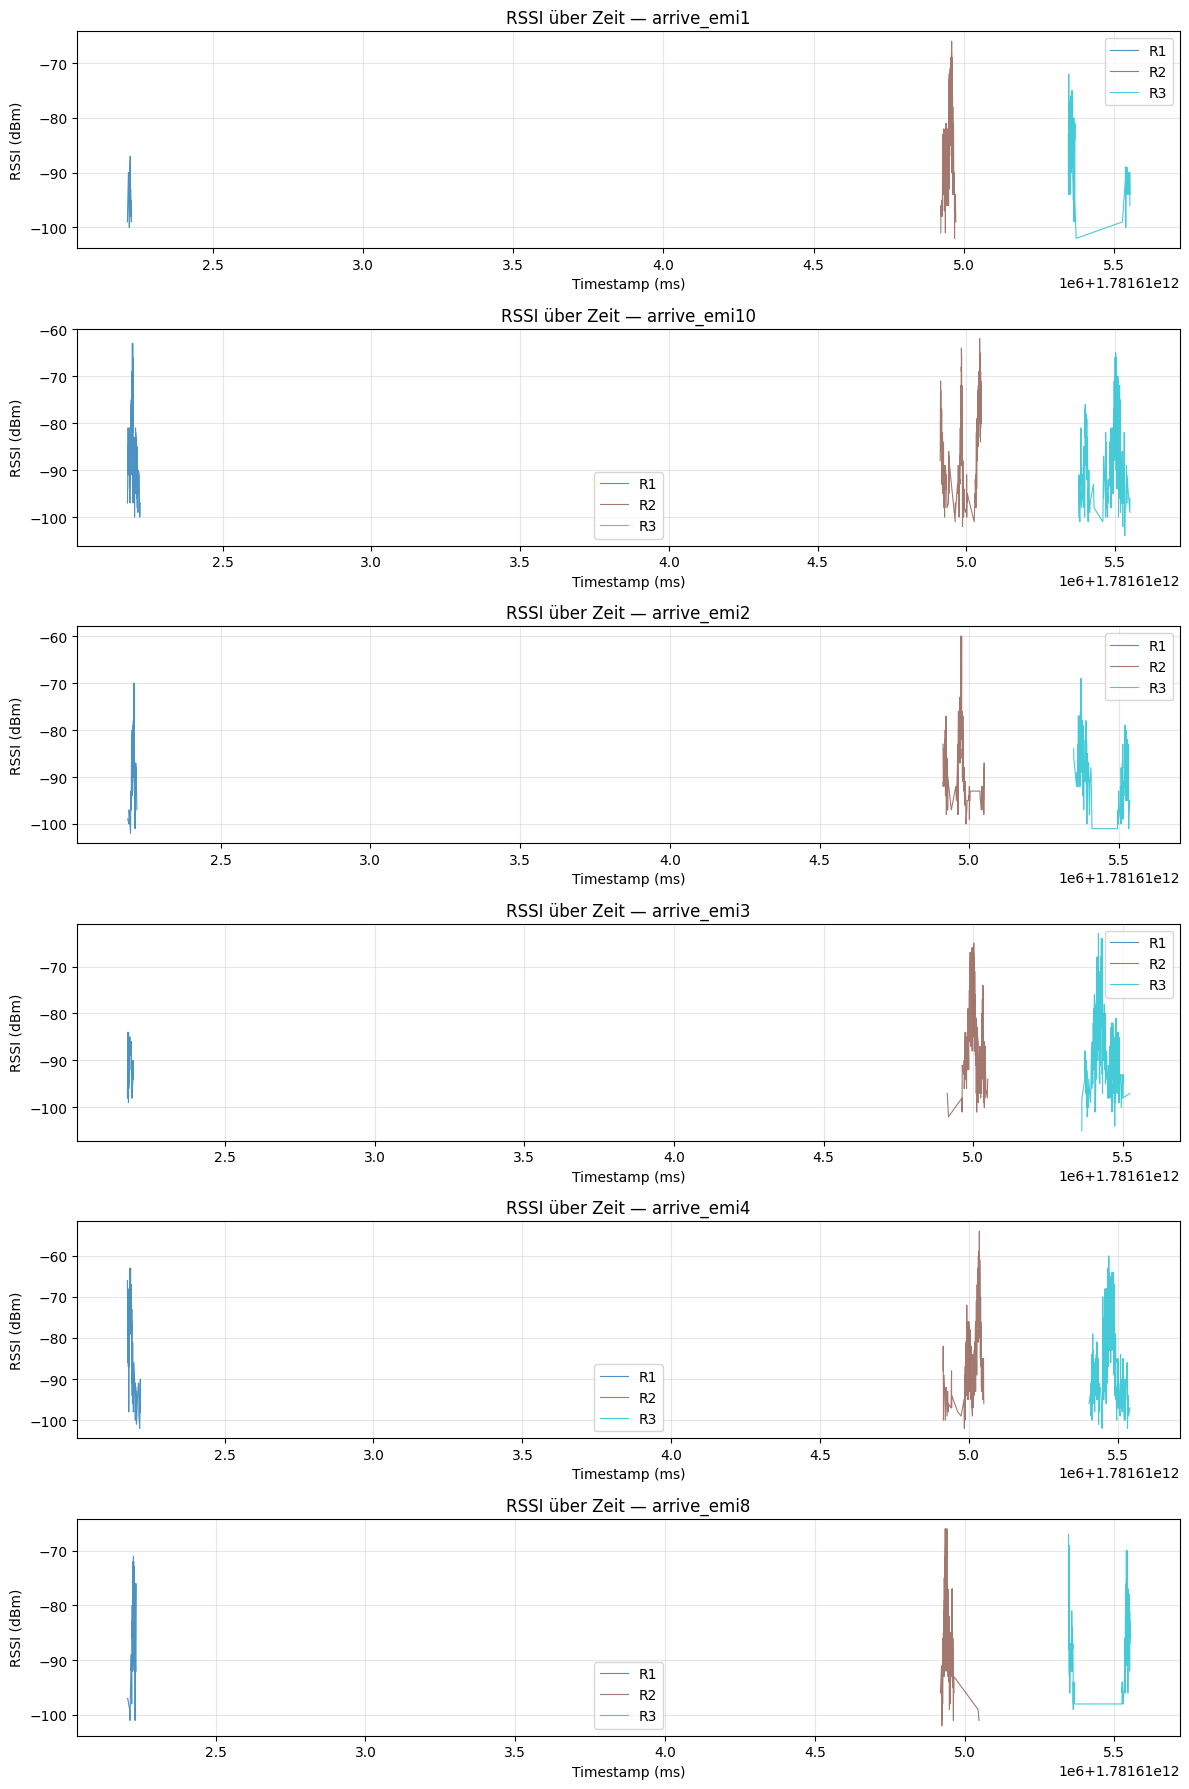

In [124]:
beacons_list = sorted(rssi_df['beacon_name'].unique())
runs_list    = sorted(rssi_df['run_id'].unique())
colors       = cm.tab10(np.linspace(0, 1, len(runs_list)))

fig, axes = plt.subplots(len(beacons_list), 1, figsize=(12, 3 * len(beacons_list)), squeeze=False)

for i, beacon in enumerate(beacons_list):
    ax = axes[i, 0]
    for run, col in zip(runs_list, colors):
        subset = rssi_df[(rssi_df['beacon_name'] == beacon) & (rssi_df['run_id'] == run)]
        if len(subset) > 1:
            subset = subset.sort_values('timestamp_ms')
            ax.plot(subset['timestamp_ms'], subset['rssi'], label=run, color=col, alpha=0.8, linewidth=0.8)
    ax.set_title(f'RSSI über Zeit — {beacon}')
    ax.set_xlabel('Timestamp (ms)'); ax.set_ylabel('RSSI (dBm)')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('rssi_over_time.png', dpi=120)
plt.show()

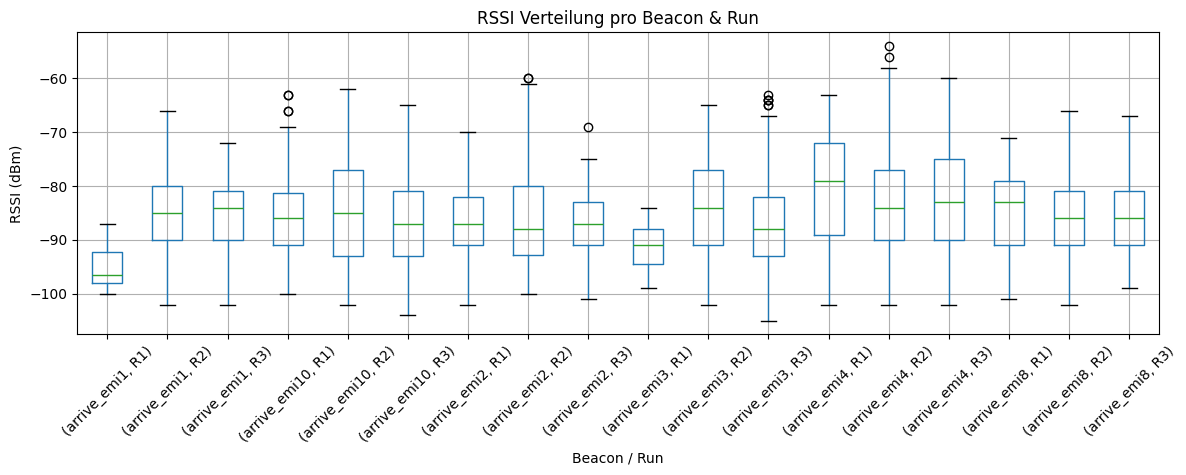

In [125]:
fig, ax = plt.subplots(figsize=(12, 5))
rssi_df.boxplot(column='rssi', by=['beacon_name', 'run_id'], ax=ax, rot=45)
ax.set_title('RSSI Verteilung pro Beacon & Run')
ax.set_xlabel('Beacon / Run'); ax.set_ylabel('RSSI (dBm)')
plt.suptitle('')
plt.tight_layout()
#plt.savefig('rssi_boxplot.png', dpi=120)
plt.show()

## 3 — Stockwerk-Klassifikation

In [126]:
eg_beacons = [b for b, (_, _, f) in BEACON_POSITIONS.items() if f == 0]
og_beacons = [b for b, (_, _, f) in BEACON_POSITIONS.items() if f == 1]
print(f'EG-Beacons ({len(eg_beacons)}): {eg_beacons}')
print(f'OG-Beacons ({len(og_beacons)}): {og_beacons}')

def estimate_floor(rssi_window: pd.DataFrame) -> int:
    """Heuristik: Stärkere mittlere RSSI = wahrscheinlich selbes Stockwerk."""
    rssi_eg = rssi_window[rssi_window['beacon_name'].isin(eg_beacons)]['rssi'].mean()
    rssi_og = rssi_window[rssi_window['beacon_name'].isin(og_beacons)]['rssi'].mean()
    if pd.isna(rssi_eg) and pd.isna(rssi_og): return -1
    if pd.isna(rssi_eg): return 1
    if pd.isna(rssi_og): return 0
    return 0 if rssi_eg >= rssi_og else 1

EG-Beacons (3): ['arrive_emi4', 'arrive_emi8', 'arrive_emi10']
OG-Beacons (3): ['arrive_emi1', 'arrive_emi2', 'arrive_emi3']


## 4 — Distanzschätzung via Log-Distance Path Loss

In [ ]:
# ── Kalibrierungsparameter ──────────────────────────────────────────
RSSI_0         = -50    # RSSI bei 1m (kalibrieren!)
PATH_LOSS_EXP  = 3.5    # n=3.5 für Innenraum mit Wänden (war vermutlich 2.0)
FLOOR_HEIGHT_M = 3.0    # echte Etagenhöhe in Metern
USE_OTHER_FLOOR = True  # True = andere Etagen mit Penalty, False = ignorieren

def rssi_to_distance(rssi: float, floor_delta: int = 0) -> float:
    """
    Inverse Log-Distance Path Loss mit Pythagoras-Floor-Korrektur.
    floor_delta=0 → gleiche Etage (normal)
    floor_delta>0 → andere Etage → Pythagoras statt additiver Penalty
    """
    if floor_delta != 0 and not USE_OTHER_FLOOR:
        return np.nan   # andere Etage ignorieren

    # Horizontale Distanz aus RSSI
    base_dist = 10.0 ** ((RSSI_0 - rssi) / (10.0 * PATH_LOSS_EXP))

    if floor_delta == 0:
        return base_dist

    # Pythagoras: 3D-Distanz mit Etagenhöhe
    vertical = abs(floor_delta) * FLOOR_HEIGHT_M
    return np.sqrt(base_dist**2 + vertical**2)


# ── Anwenden ────────────────────────────────────────────────────────
rssi_df['beacon_floor'] = rssi_df['beacon_name'].map(
    lambda b: BEACON_POSITIONS.get(b, (None, None, 0))[2]
)
rssi_df['floor_delta'] = rssi_df['beacon_floor'].fillna(0).astype(int)
rssi_df['dist_est_m']  = rssi_df.apply(
    lambda r: rssi_to_distance(r['rssi'], r['floor_delta']), axis=1
)

# Andere Etagen rausfiltern (wenn USE_OTHER_FLOOR=False)
rssi_df_clean = rssi_df.dropna(subset=['dist_est_m'])

print('Distanzschätzungen (Beispiel):')
print(rssi_df_clean[['run_id','beacon_name','rssi','floor_delta','dist_est_m']].head(10).round(2))

Distanzschätzungen (Beispiel):
   run_id  beacon_name  rssi  floor_delta  dist_est_m
1      R1  arrive_emi4 -66.0            0        2.87
2      R1  arrive_emi4 -67.0            0        3.06
3      R1  arrive_emi4 -66.0            0        2.87
4      R1  arrive_emi4 -72.0            0        4.25
5      R1  arrive_emi4 -78.0            0        6.31
8      R1  arrive_emi4 -76.0            0        5.53
11     R1  arrive_emi4 -77.0            0        5.91
12     R1  arrive_emi4 -71.0            0        3.98
14     R1  arrive_emi4 -77.0            0        5.91
16     R1  arrive_emi4 -72.0            0        4.25


## 5 — Multilateration (Least Squares)

In [128]:
def multilaterate_ls(beacon_positions: list, distances: list) -> tuple:
    """
    Least Squares Multilateration 2D.
    Linearisierung durch Subtraktion des ersten Ankerpunkts.
    Quelle: PositionEstimation.pdf S.24-26.
    """
    if len(beacon_positions) < 3:
        return None, None, None
    beacons = np.array(beacon_positions)
    dists   = np.array(distances)
    x1, y1, d1 = beacons[0,0], beacons[0,1], dists[0]
    A, b = [], []
    for i in range(1, len(beacons)):
        xi, yi, di = beacons[i,0], beacons[i,1], dists[i]
        A.append([2*(xi-x1), 2*(yi-y1)])
        b.append(di**2 - d1**2 - xi**2 + x1**2 - yi**2 + y1**2)
    A, b = np.array(A), np.array(b)
    result, residuals, rank, _ = np.linalg.lstsq(A, b, rcond=None)
    res = float(residuals[0]) if len(residuals) > 0 else np.nan
    return result[0], result[1], res


def estimate_positions_for_run(run_id: str, window_ms: int = 1000) -> pd.DataFrame:
    run_data = rssi_df[rssi_df['run_id'] == run_id].sort_values('timestamp_ms')
    t_start, t_end = run_data['timestamp_ms'].min(), run_data['timestamp_ms'].max()
    results, t = [], t_start

    while t < t_end:
        window = run_data[
            (run_data['timestamp_ms'] >= t) &
            (run_data['timestamp_ms'] <  t + window_ms)
        ]

        # 1. Stockwerk schätzen
        est_floor = estimate_floor(window)

        # 2. NUR Beacons dieses Stockwerks verwenden
        floor_beacons = [
            b for b, (_, _, f) in BEACON_POSITIONS.items()
            if f == est_floor
        ]

        avg = window.groupby('beacon_name').agg(
            rssi=('rssi', 'mean'), floor_delta=('floor_delta', 'first')
        ).reset_index()

        # Nur gleiche-Stockwerk-Beacons + müssen in BEACON_POSITIONS sein
        avg = avg[avg['beacon_name'].isin(floor_beacons)].copy()
        avg['dist'] = avg.apply(
            lambda r: rssi_to_distance(r['rssi'], 0),  # floor_delta=0 da gleicher Floor
            axis=1
        )

        positions = [
            (BEACON_POSITIONS[b][0], BEACON_POSITIONS[b][1])
            for b in avg['beacon_name']
        ]

        x_est, y_est, residual = multilaterate_ls(positions, avg['dist'].tolist())

        results.append({
            'run_id':     run_id,
            'timestamp_ms': t + window_ms // 2,
            'x_est':      x_est,
            'y_est':      y_est,
            'floor_est':  est_floor,
            'n_beacons':  len(avg),
            'residual':   residual,
        })
        t += window_ms

    return pd.DataFrame(results).dropna(subset=['x_est', 'y_est'])


all_positions = pd.concat(
    [estimate_positions_for_run(r) for r in runs_df['run_id']],
    ignore_index=True
)
print(f'Positionsschätzungen gesamt: {len(all_positions)}')
print(all_positions.head(10).round(2))

Positionsschätzungen gesamt: 17
  run_id   timestamp_ms   x_est   y_est  floor_est  n_beacons residual
0     R2  1781614923302  -84.30   82.13          0          3      NaN
1     R2  1781614928302  -75.53  134.33          0          3      NaN
2     R2  1781614930302  -78.05   98.70          0          3      NaN
3     R2  1781614939302  -68.11  165.43          0          3      NaN
4     R2  1781614940302  -74.58  137.86          0          3      NaN
5     R2  1781614941302  -77.31  111.36          0          3      NaN
6     R2  1781614962302  -47.83  322.73          1          3      NaN
7     R2  1781614963302  -56.66  301.38          1          3      NaN
8     R2  1781614973302 -104.07  -29.38          1          3      NaN
9     R2  1781615045302  -95.65   35.80          0          3      NaN


In [129]:
from scipy.optimize import minimize

FLOOR_HEIGHT_M = 4.0  # Geschosshohe in Metern — anpassen!

# Beacon-Positionen um Z erweitern
BEACON_POSITIONS_3D = {
    name: (x, y, floor * FLOOR_HEIGHT_M)
    for name, (x, y, floor) in BEACON_POSITIONS.items()
}

def multilaterate_3d(beacon_positions_3d: list, distances: list) -> tuple:
    """
    3D Least Squares Multilateration.
    Gibt (x, y, z) zurück — z dann in Stockwerk umrechnen.
    """
    if len(beacon_positions_3d) < 4:
        # Mit 3 Beacons: z fixieren auf wahrscheinlichstes Stockwerk
        # und 2D lösen — Fallback
        return None, None, None, None

    beacons = np.array(beacon_positions_3d)  # shape (n, 3)
    dists   = np.array(distances)

    def residual(pos):
        diff = beacons - pos  # (n, 3)
        dist_est = np.sqrt((diff**2).sum(axis=1))
        return np.sum((dist_est - dists)**2)

    x0 = [beacons[:, 0].mean(), beacons[:, 1].mean(), beacons[:, 2].mean()]
    result = minimize(residual, x0=x0, method='Nelder-Mead',
                      options={'xatol': 0.1, 'fatol': 0.1, 'maxiter': 2000})

    x_est, y_est, z_est = result.x
    floor_est = 0 if z_est < FLOOR_HEIGHT_M / 2 else 1
    return x_est, y_est, z_est, floor_est

def estimate_positions_for_run_drei(run_id: str, window_ms: int = 2000) -> pd.DataFrame:
    run_data = rssi_df[rssi_df['run_id'] == run_id].sort_values('timestamp_ms')
    t_start, t_end = run_data['timestamp_ms'].min(), run_data['timestamp_ms'].max()
    results, t = [], t_start

    while t < t_end:
        window = run_data[
            (run_data['timestamp_ms'] >= t) &
            (run_data['timestamp_ms'] <  t + window_ms)
        ]
        avg = window.groupby('beacon_name').agg(
            rssi=('rssi', 'mean')
        ).reset_index()
        avg = avg[avg['beacon_name'].isin(BEACON_POSITIONS_3D)].copy()
        avg['dist'] = avg['rssi'].apply(rssi_to_distance)  # kein floor_delta mehr nötig!

        positions_3d = [BEACON_POSITIONS_3D[b] for b in avg['beacon_name']]
        x_est, y_est, z_est, floor_est = multilaterate_3d(positions_3d, avg['dist'].tolist())

        results.append({
            'run_id':       run_id,
            'timestamp_ms': t + window_ms // 2,
            'x_est':        x_est,
            'y_est':        y_est,
            'z_est':        z_est,
            'floor_est':    floor_est,
            'n_beacons':    len(avg),
        })
        t += window_ms // 2  # 50% Überlappung

    return pd.DataFrame(results).dropna(subset=['x_est', 'y_est'])

all_positions = pd.concat(
    [estimate_positions_for_run_drei(r) for r in runs_df['run_id']],
    ignore_index=True
)
print(f'Positionsschätzungen gesamt: {len(all_positions)}')
print(all_positions.head(10).round(2))

Positionsschätzungen gesamt: 94
  run_id   timestamp_ms   x_est  y_est  z_est  floor_est  n_beacons
0     R1  1781612188694  109.10   6.56 -10.90        0.0          4
1     R1  1781612189694  107.92   7.33 -12.03        0.0          4
2     R1  1781612190694  108.30   8.68 -10.34        0.0          4
3     R1  1781612191694  107.87   9.93  -9.03        0.0          4
4     R1  1781612193694  109.04  14.95  -5.82        0.0          4
5     R1  1781612194694  105.21  16.27  -5.62        0.0          4
6     R1  1781612204694   91.98  12.87  -7.78        0.0          4
7     R1  1781612211694   96.87   0.55   1.63        0.0          4
8     R1  1781612212694   98.02   0.19   8.78        1.0          4
9     R1  1781612215694   91.85  -7.48   3.93        1.0          4


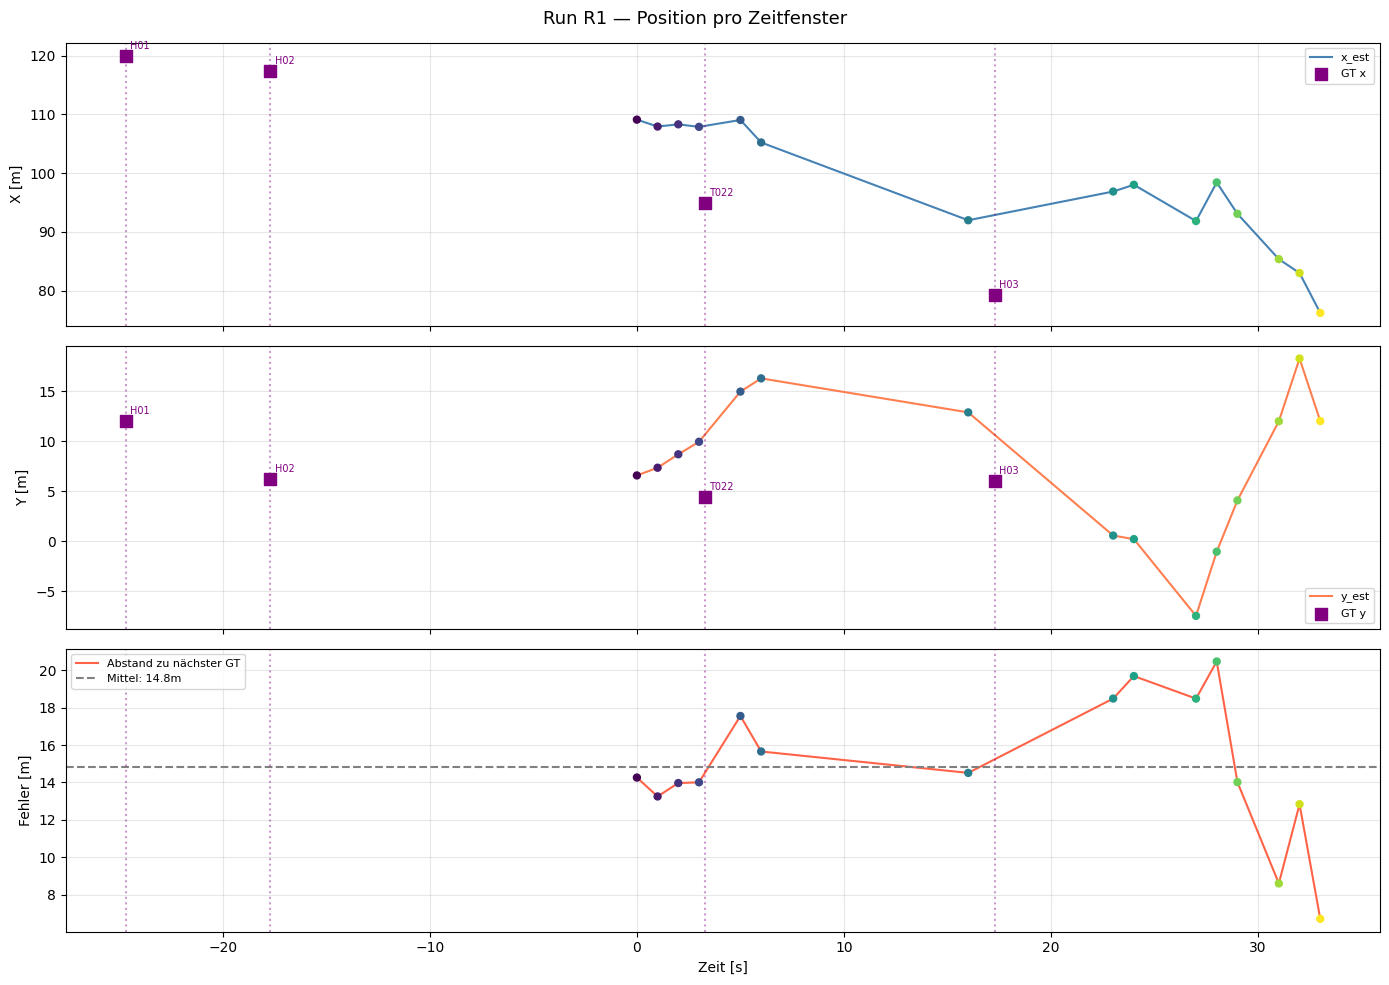

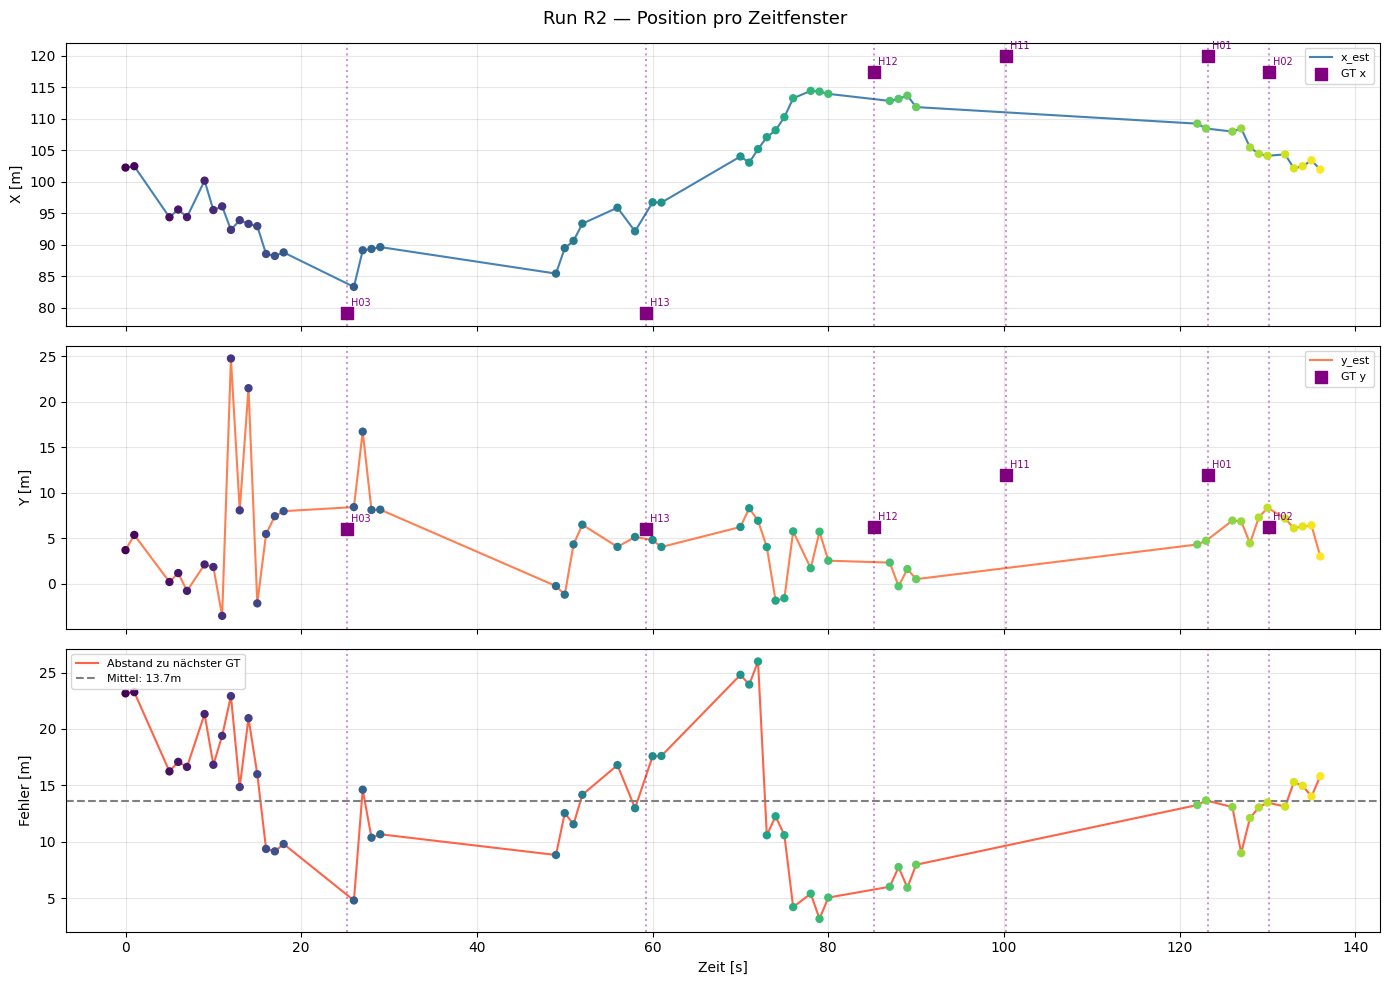

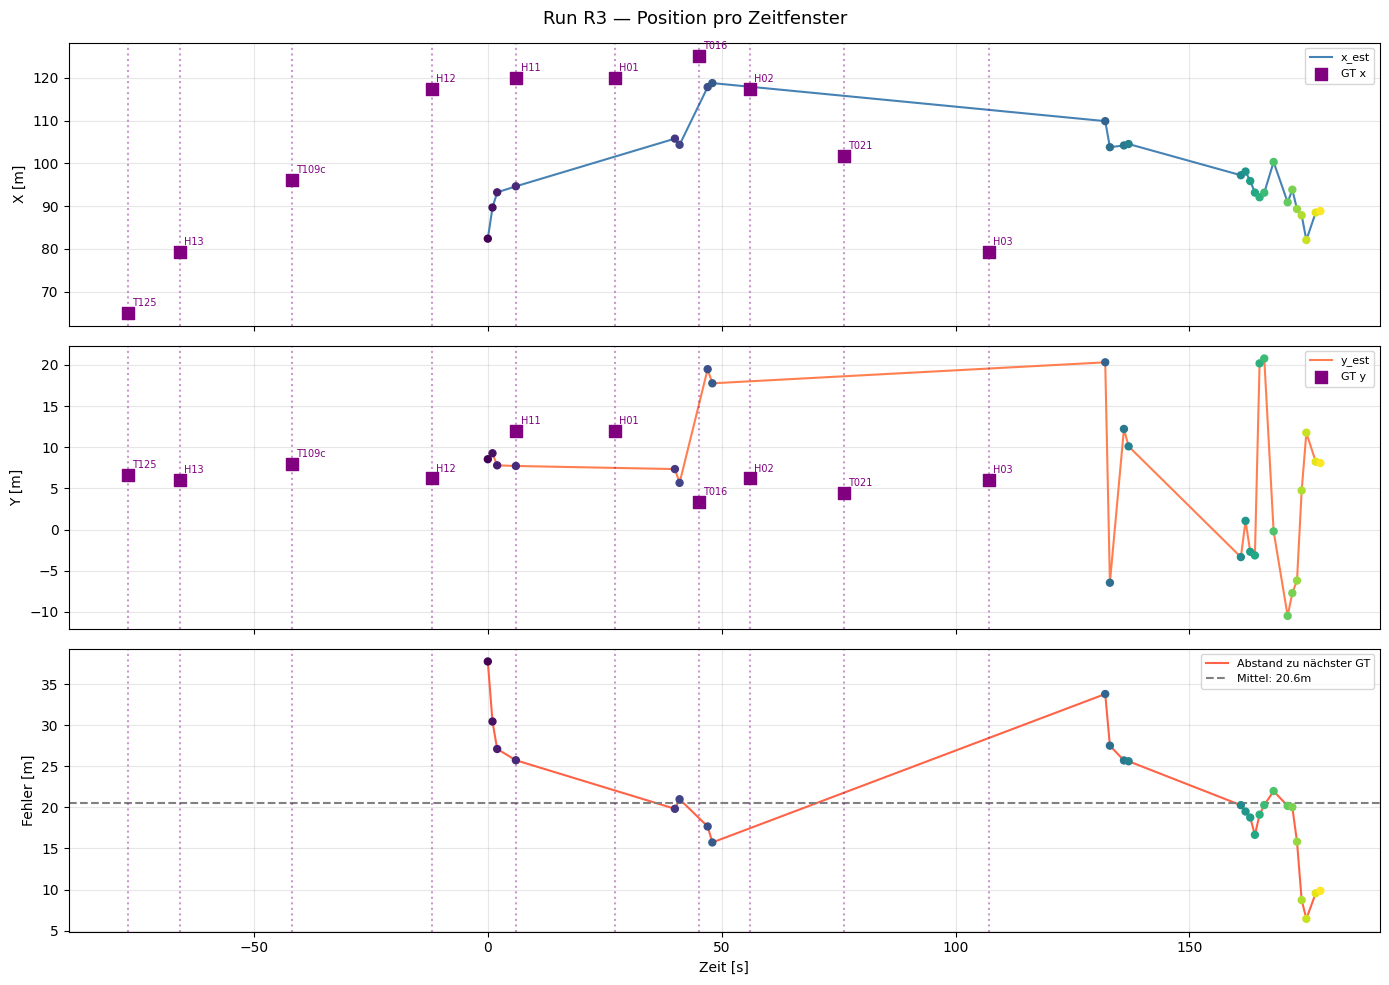

In [130]:
## 6b — Position pro Zeitfenster (Timeline)

for run in runs_list:
    df_run = all_positions[all_positions['run_id']==run].sort_values('timestamp_ms').reset_index(drop=True)
    gt_run = gt_df[gt_df['run_id']==run].sort_values('timestamp_ms')
    if len(df_run) == 0: continue

    # Zeitachse normalisieren auf Sekunden ab Start
    t0 = df_run['timestamp_ms'].iloc[0]
    df_run = df_run.copy(); df_run['t_sec'] = (df_run['timestamp_ms'] - t0) / 1000
    if len(gt_run) > 0:
        gt_run = gt_run.copy(); gt_run['t_sec'] = (gt_run['timestamp_ms'] - t0) / 1000

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f'Run {run} — Position pro Zeitfenster', fontsize=13)

    # X über Zeit
    axes[0].plot(df_run['t_sec'], df_run['x_est'], color='steelblue', linewidth=1.5, label='x_est')
    axes[0].scatter(df_run['t_sec'], df_run['x_est'], c=range(len(df_run)), cmap='viridis', s=25, zorder=3)
    if len(gt_run) > 0:
        axes[0].scatter(gt_run['t_sec'], gt_run['x_m'], color='purple', s=80, marker='s', zorder=4, label='GT x')
        for _, r in gt_run.iterrows():
            axes[0].axvline(r['t_sec'], color='purple', linestyle=':', alpha=0.4)
            axes[0].annotate(r['tuer_id'], (r['t_sec'], r['x_m']), textcoords='offset points', xytext=(3,5), fontsize=7, color='purple')
    axes[0].set_ylabel('X [m]'); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

    # Y über Zeit
    axes[1].plot(df_run['t_sec'], df_run['y_est'], color='coral', linewidth=1.5, label='y_est')
    axes[1].scatter(df_run['t_sec'], df_run['y_est'], c=range(len(df_run)), cmap='viridis', s=25, zorder=3)
    if len(gt_run) > 0:
        axes[1].scatter(gt_run['t_sec'], gt_run['y_m'], color='purple', s=80, marker='s', zorder=4, label='GT y')
        for _, r in gt_run.iterrows():
            axes[1].axvline(r['t_sec'], color='purple', linestyle=':', alpha=0.4)
            axes[1].annotate(r['tuer_id'], (r['t_sec'], r['y_m']), textcoords='offset points', xytext=(3,5), fontsize=7, color='purple')
    axes[1].set_ylabel('Y [m]'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

    # Fehler zur nächsten Groundtruth
    if len(gt_run) > 0:
        errors = []
        for _, row in df_run.iterrows():
            idx = (gt_run['timestamp_ms'] - row['timestamp_ms']).abs().idxmin()
            gt_nearest = gt_run.loc[idx]
            err = np.sqrt((row['x_est']-gt_nearest['x_m'])**2 + (row['y_est']-gt_nearest['y_m'])**2)
            errors.append(err)
        axes[2].plot(df_run['t_sec'], errors, color='tomato', linewidth=1.5, label='Abstand zu nächster GT')
        axes[2].scatter(df_run['t_sec'], errors, c=range(len(df_run)), cmap='viridis', s=25, zorder=3)
        axes[2].axhline(np.mean(errors), color='gray', linestyle='--', label=f'Mittel: {np.mean(errors):.1f}m')
        for _, r in gt_run.iterrows():
            axes[2].axvline(r['t_sec'], color='purple', linestyle=':', alpha=0.4)
            axes[2].annotate(r['tuer_id'], (r['t_sec'], 0), textcoords='offset points', xytext=(3,5), fontsize=7, color='purple')
        axes[2].set_ylabel('Fehler [m]'); axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)
    else:
        axes[2].text(0.5, 0.5, 'Keine Groundtruth-Daten', ha='center', va='center', transform=axes[2].transAxes)

    axes[2].set_xlabel('Zeit [s]')
    plt.tight_layout()
    plt.savefig(f'position_timeline_{run}.png', dpi=130)
    plt.show()

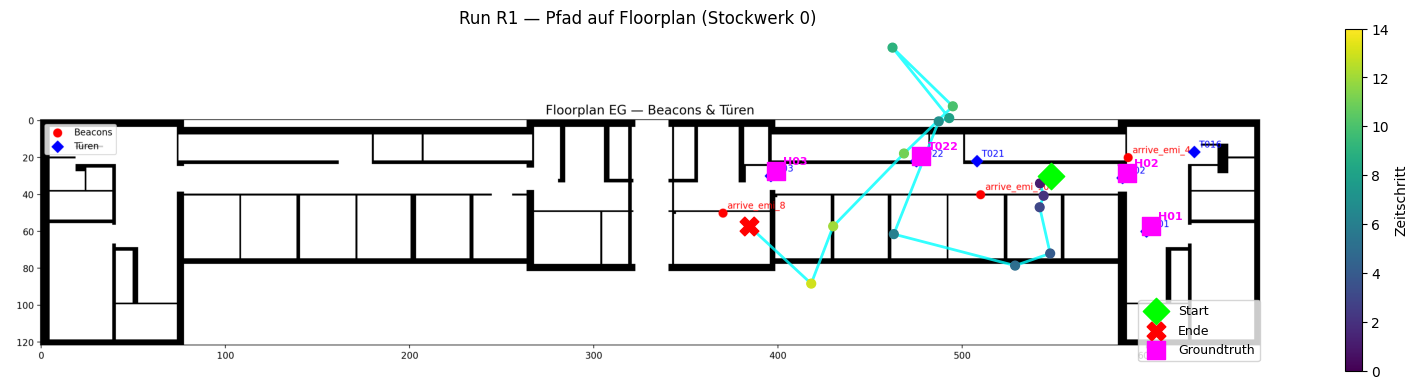

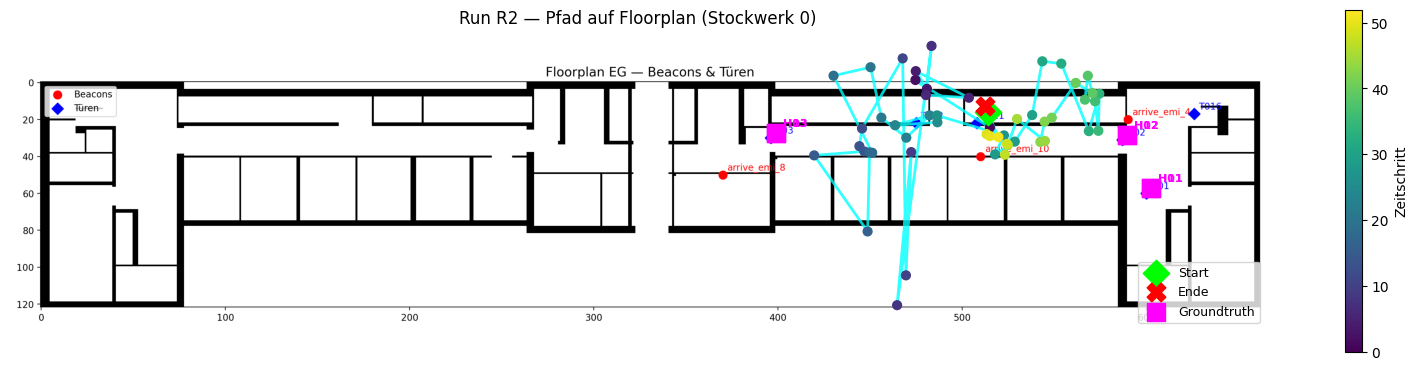

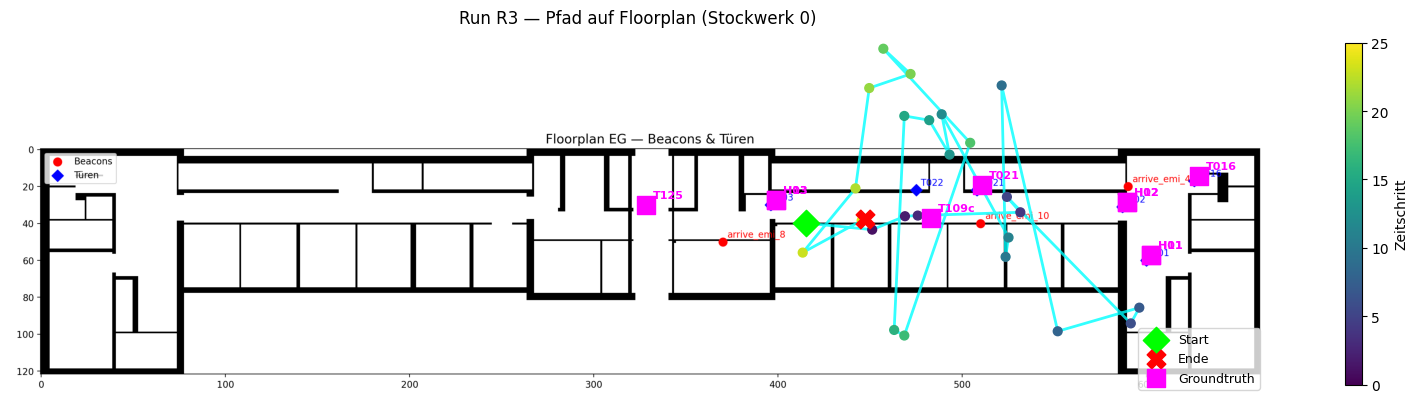

In [131]:
## 6c — Pfad auf Floorplan (Meter → Pixel)

import matplotlib.image as mpimg

SCALE = 0.2  # 1 Pixel = 0.2 Meter → 5 px/m

FLOORPLAN = {
    0: '../data/floorplans/emi_map_eg_beacons_doors.png',
    1: '../data/floorplans/emi_map_og_beacons_doors.png',
}

# Kalibrierungsparameter (EG)
OCC_XMIN   = 30        # xs.min() aus occupancy_map
OCC_YMIN   = 13           # ys.min() aus occupancy_map
SCALE_F    = 4.009        # occ→img (RESOLUTION=0.05m)
PX_PER_M   = 28.00        # px/m in emi_map img

ORIGIN_X   = OCC_XMIN * SCALE_F   # = 417 px
ORIGIN_Y   = OCC_YMIN * SCALE_F   # = 204 px

def meter_to_pixel(x_m, y_m):
    px = int(round(ORIGIN_X + x_m * PX_PER_M))
    py = int(round(ORIGIN_Y + y_m * PX_PER_M))
    return px, py

for run in runs_list:
    df_run = all_positions[all_positions['run_id']==run].sort_values('timestamp_ms')
    gt_run = gt_df[gt_df['run_id']==run]
    if len(df_run) == 0: continue

    floor = int(df_run['floor_est'].mode()[0]) if 'floor_est' in df_run else 0
    img   = mpimg.imread(FLOORPLAN[floor])

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.imshow(img)
    ax.axis('off')

    # Pfad
    xs = [meter_to_pixel(x, y)[0] for x, y in zip(df_run['x_est'], df_run['y_est'])]
    ys = [meter_to_pixel(x, y)[1] for x, y in zip(df_run['x_est'], df_run['y_est'])]
    ax.plot(xs, ys, color='cyan', linewidth=2, alpha=0.8, zorder=2)
    sc = ax.scatter(xs, ys, c=range(len(xs)), cmap='viridis', s=40, zorder=3)
    plt.colorbar(sc, ax=ax, label='Zeitschritt', shrink=0.6)
    ax.scatter(xs[0],  ys[0],  color='lime', s=180, marker='D', zorder=5, label='Start')
    ax.scatter(xs[-1], ys[-1], color='red',  s=180, marker='X', zorder=5, label='Ende')

    #Groundtruth
    if len(gt_run) > 0:
         gxs = [meter_to_pixel(x, y)[0] for x, y in zip(gt_run['x_m'], gt_run['y_m'])]
         gys = [meter_to_pixel(x, y)[1] for x, y in zip(gt_run['x_m'], gt_run['y_m'])]
         ax.scatter(gxs, gys, color='magenta', s=150, marker='s', zorder=6, label='Groundtruth')
         for (gx, gy), (_, r) in zip(zip(gxs, gys), gt_run.iterrows()):
             ax.annotate(r['tuer_id'], (gx, gy), textcoords='offset points',
                         xytext=(5, 5), fontsize=8, color='magenta',
                         fontweight='bold')

    ax.set_title(f'Run {run} — Pfad auf Floorplan (Stockwerk {floor})', fontsize=12)
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    #plt.savefig(f'path_on_map_{run}.png', dpi=130)
    plt.show()

## 7 — Positionswahrscheinlichkeit (KDE Heatmap)

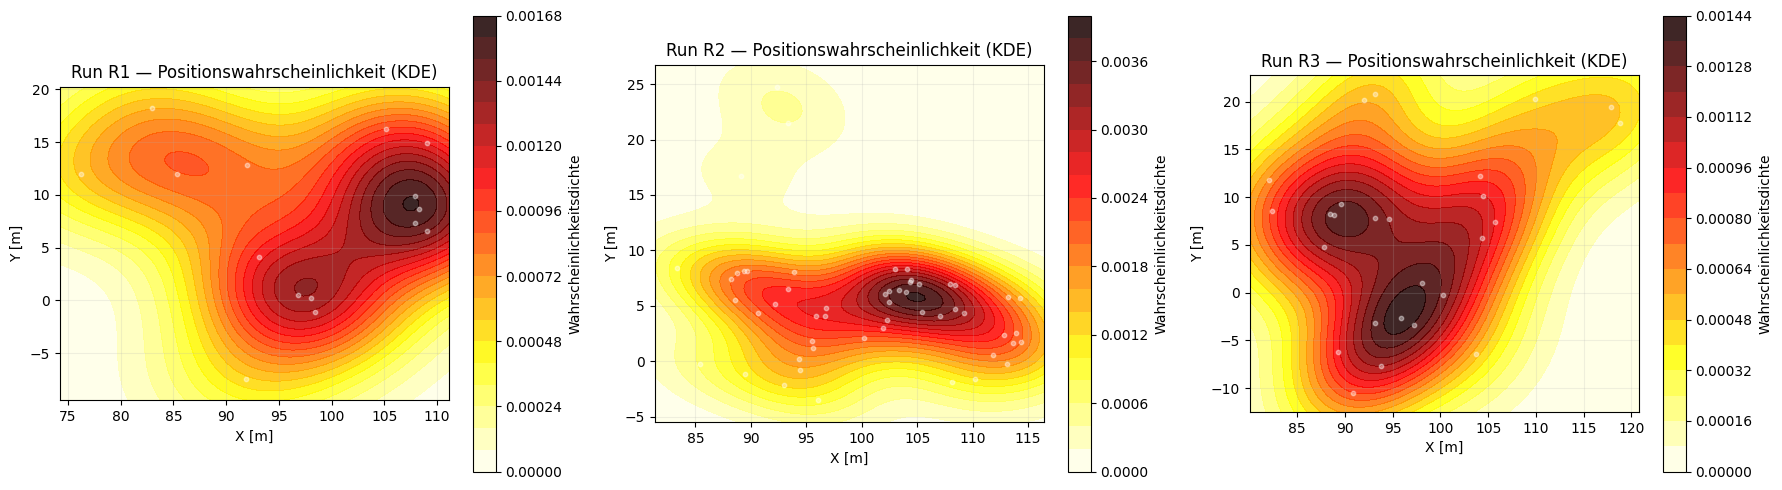

In [132]:
fig, axes = plt.subplots(1, len(runs_list), figsize=(6*len(runs_list), 5), squeeze=False)

for ax, run in zip(axes[0], runs_list):
    df_run = all_positions[all_positions['run_id'] == run].dropna()
    if len(df_run) < 5:
        ax.set_title(f'Run {run} — zu wenig Daten'); continue
    xy  = np.vstack([df_run['x_est'], df_run['y_est']])
    kde = gaussian_kde(xy)
    x_grid = np.linspace(df_run['x_est'].min()-2, df_run['x_est'].max()+2, 100)
    y_grid = np.linspace(df_run['y_est'].min()-2, df_run['y_est'].max()+2, 100)
    X, Y = np.meshgrid(x_grid, y_grid)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    im = ax.contourf(X, Y, Z, levels=20, cmap='hot_r', alpha=0.85)
    plt.colorbar(im, ax=ax, label='Wahrscheinlichkeitsdichte')
    ax.scatter(df_run['x_est'], df_run['y_est'], s=10, color='white', alpha=0.4, zorder=2)
    ax.set_title(f'Run {run} — Positionswahrscheinlichkeit (KDE)')
    ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)

plt.tight_layout()
#plt.savefig('position_probability_kde.png', dpi=130)
plt.show()

  run_id   beacon_name       mean       std  count
0     R1  arrive_emi10  11.498069  5.278769    142
1     R1   arrive_emi4   9.467793  6.819668    141
2     R1   arrive_emi8  10.843383  5.809693     73
3     R2  arrive_emi10  11.843287  6.692096    225
4     R2   arrive_emi4  10.338313  5.782427    321
5     R2   arrive_emi8  11.790948  5.797633    192
6     R3  arrive_emi10  12.891658  6.342789    354
7     R3   arrive_emi4  10.323700  6.154691    441
8     R3   arrive_emi8  11.648267  5.345254    175


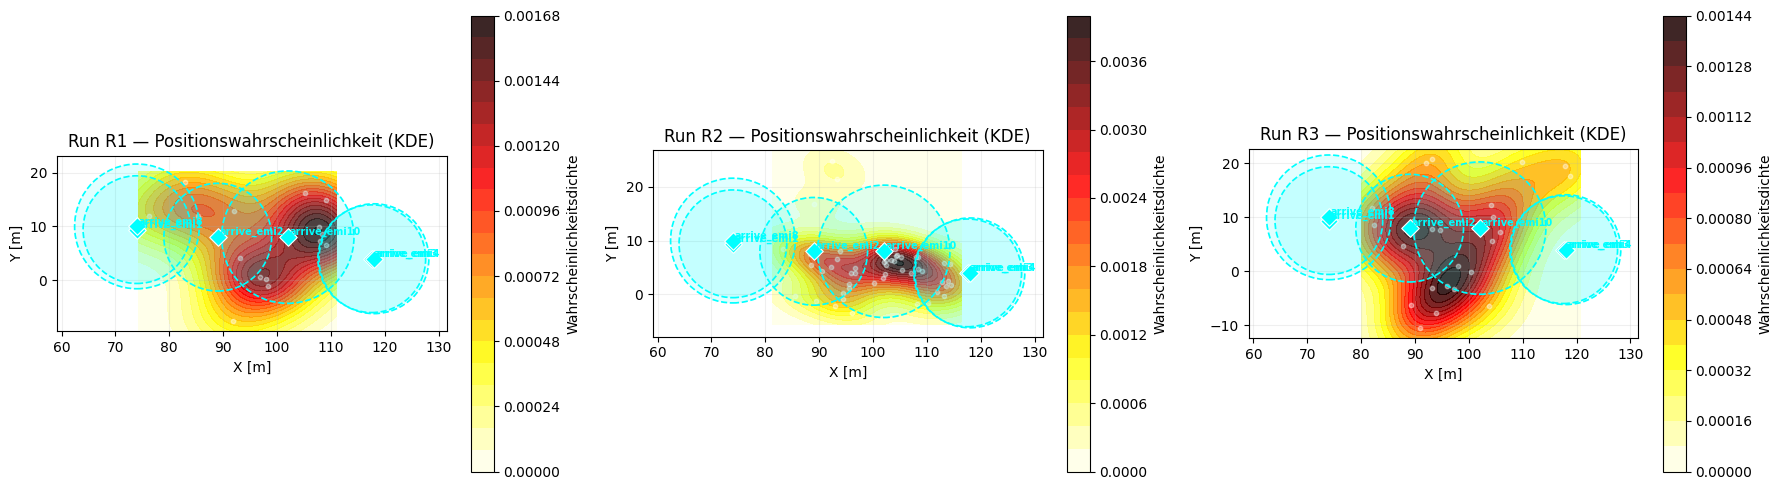

In [133]:
# Nur Beacons auf gleicher Etage verwenden
df_clean = rssi_df[rssi_df['floor_delta'] == 0].copy()
# Mittlere Distanz pro Beacon (als Fingerprint-Ersatz)
df_fingerprint = (df_clean
    .groupby(['run_id', 'beacon_name'])['dist_est_m']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
print(df_fingerprint)
fig, axes = plt.subplots(1, len(runs_list), figsize=(6*len(runs_list), 5), squeeze=False)

for ax, run in zip(axes[0], runs_list):
    df_run = all_positions[all_positions['run_id'] == run].dropna()
    if len(df_run) < 5:
        ax.set_title(f'Run {run} — zu wenig Daten'); continue

    xy  = np.vstack([df_run['x_est'], df_run['y_est']])
    kde = gaussian_kde(xy)
    x_grid = np.linspace(df_run['x_est'].min()-2, df_run['x_est'].max()+2, 100)
    y_grid = np.linspace(df_run['y_est'].min()-2, df_run['y_est'].max()+2, 100)
    X, Y = np.meshgrid(x_grid, y_grid)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    im = ax.contourf(X, Y, Z, levels=20, cmap='hot_r', alpha=0.85)
    plt.colorbar(im, ax=ax, label='Wahrscheinlichkeitsdichte')
    ax.scatter(df_run['x_est'], df_run['y_est'], s=10, color='white', alpha=0.4, zorder=2)

    # ── NEU: Beacon-Radien ──────────────────────────────────────────
    radius_per_beacon = (df_clean
    .groupby('beacon_name')['dist_est_m']
    .mean()
    .to_dict()
    )
    for name, (bx, by, bfloor) in BEACON_POSITIONS.items():
        radius = radius_per_beacon.get(name, 10)
        circle = plt.Circle((bx, by), radius,
                             color='cyan', alpha=0.12,
                             linestyle='--', linewidth=1.2,
                             fill=True, zorder=3)
        ax.add_patch(circle)
        ax.add_patch(plt.Circle((bx, by), radius,
                                color='cyan', fill=False,
                                linestyle='--', linewidth=1.2, zorder=3))

    # ── NEU: Beacon-Punkte & Labels ─────────────────────────────────
        ax.scatter(bx, by, c='cyan', s=80,
                   edgecolors='white', linewidths=0.8,
                   zorder=4, marker='D')
        ax.annotate(name.replace('arrive_emi_', 'B'),
                    (bx + 0.4, by + 0.4),
                    color='cyan', fontsize=7,
                    fontweight='bold', zorder=5)
    # ────────────────────────────────────────────────────────────────

    ax.set_title(f'Run {run} — Positionswahrscheinlichkeit (KDE)')
    ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 8 — Fehleranalyse (Groundtruth aus DB)

In [134]:
def compute_errors(run_id: str, pos_df: pd.DataFrame, gt: pd.DataFrame) -> pd.DataFrame:
    """Findet zum GT-Zeitpunkt die nächste Schätzung und berechnet Euklidischen Fehler."""
    errors = []
    for _, row in gt.iterrows():
        idx = (pos_df['timestamp_ms'] - row['timestamp_ms']).abs().argsort().iloc[0]
        est = pos_df.iloc[idx]
        err = np.sqrt((est['x_est'] - row['x_m'])**2 + (est['y_est'] - row['y_m'])**2)
        errors.append({
            'run_id':  run_id,
            'tuer_id': row['tuer_id'],
            'x_gt':    row['x_m'],   'y_gt': row['y_m'],
            'x_est':   est['x_est'], 'y_est': est['y_est'],
            'error_m': err
        })
    return pd.DataFrame(errors)


error_dfs = []
for run_id in runs_df['run_id']:
    gt_run  = gt_df[gt_df['run_id'] == run_id]
    run_pos = all_positions[all_positions['run_id'] == run_id]
    if gt_run.empty:
        print(f'Run {run_id}: Keine Groundtruth-Koordinaten in DB.')
        continue
    error_dfs.append(compute_errors(run_id, run_pos, gt_run))

if error_dfs:
    all_errors = pd.concat(error_dfs, ignore_index=True)
    print('=== Fehlerstatistik (Meter) ===')
    print(all_errors.groupby('run_id')['error_m'].agg(['mean','median','std','max']).round(2))
    print(f'\nGesamtfehler (RMSE): {np.sqrt((all_errors["error_m"]**2).mean()):.2f} m')
    print('\nDetail:')
    print(all_errors.round(2))
else:
    print('Fehleranalyse: door_positions in DB befüllen.')

=== Fehlerstatistik (Meter) ===
         mean  median   std    max
run_id                            
R1      12.25   13.10  2.81  14.51
R2      11.60   13.57  5.05  17.58
R3      19.59   17.58  9.75  35.11

Gesamtfehler (RMSE): 17.68 m

Detail:
   run_id tuer_id   x_gt  y_gt   x_est  y_est  error_m
0      R1     H01  120.0  12.0  109.10   6.56    12.19
1      R1     H02  117.4   6.2  109.10   6.56     8.31
2      R1    T022   95.0   4.4  107.87   9.93    14.01
3      R1     H03   79.2   6.0   91.98  12.87    14.51
4      R2     H03   79.2   6.0   83.32   8.43     4.79
5      R2     H13   79.2   6.0   96.74   4.82    17.58
6      R2     H12  117.4   6.2  112.80   2.34     6.00
7      R2     H11  120.0  12.0  111.83   0.52    14.09
8      R2     H01  120.0  12.0  108.43   4.74    13.66
9      R2     H02  117.4   6.2  104.10   8.36    13.47
10     R3    T125   65.0   6.6   82.37   8.54    17.48
11     R3     H13   79.2   6.0   82.37   8.54     4.06
12     R3   T109c   96.0   8.0   82.37 

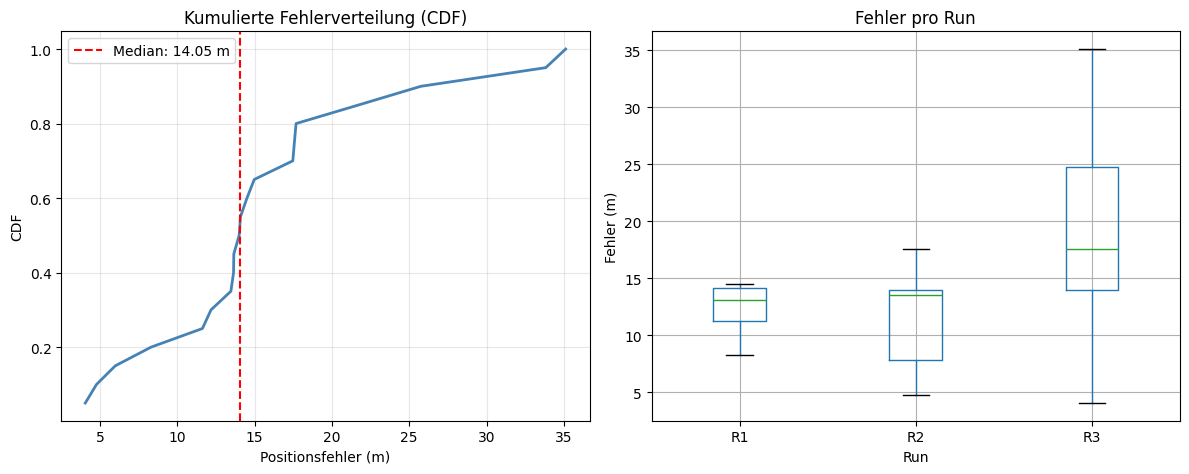

In [135]:
if error_dfs and len(all_errors) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sorted_err = np.sort(all_errors['error_m'])
    cdf = np.arange(1, len(sorted_err)+1) / len(sorted_err)
    axes[0].plot(sorted_err, cdf, color='steelblue', linewidth=2)
    axes[0].axvline(np.median(sorted_err), color='red', linestyle='--',
                    label=f'Median: {np.median(sorted_err):.2f} m')
    axes[0].set_xlabel('Positionsfehler (m)'); axes[0].set_ylabel('CDF')
    axes[0].set_title('Kumulierte Fehlerverteilung (CDF)')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    all_errors.boxplot(column='error_m', by='run_id', ax=axes[1])
    axes[1].set_title('Fehler pro Run'); axes[1].set_xlabel('Run')
    axes[1].set_ylabel('Fehler (m)'); plt.suptitle('')
    plt.tight_layout()
    #plt.savefig('error_analysis.png', dpi=130)
    plt.show()
else:
    print('Fehler-Plot: Groundtruth-Daten erforderlich.')